In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_path = "../../dataset/train"

emotion_counts = {}

for emotion in os.listdir(train_path):
    emotion_counts[emotion] = len(
        os.listdir(os.path.join(train_path, emotion))
    )

emotion_counts

{'angry': 3995,
 'disgust': 436,
 'fear': 4097,
 'happy': 7215,
 'neutral': 4965,
 'sad': 4830,
 'surprise': 3171}

In [3]:
df = pd.DataFrame(
    emotion_counts.items(),
    columns=["Emotion", "Count"]
)

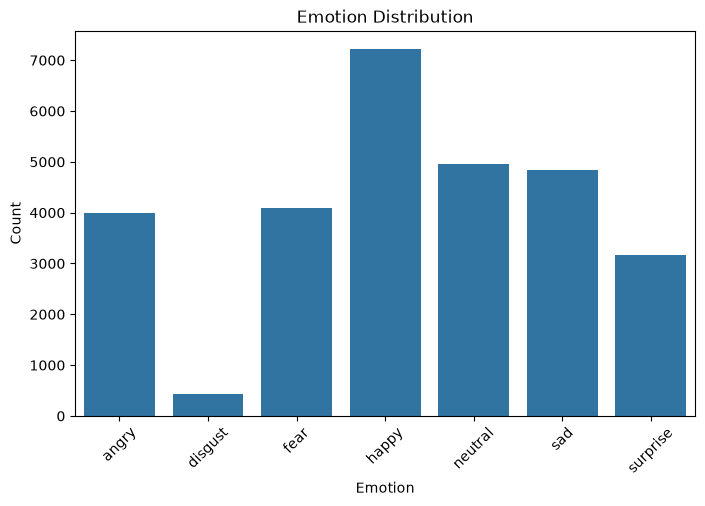

In [4]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x="Emotion",
            y="Count")

plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

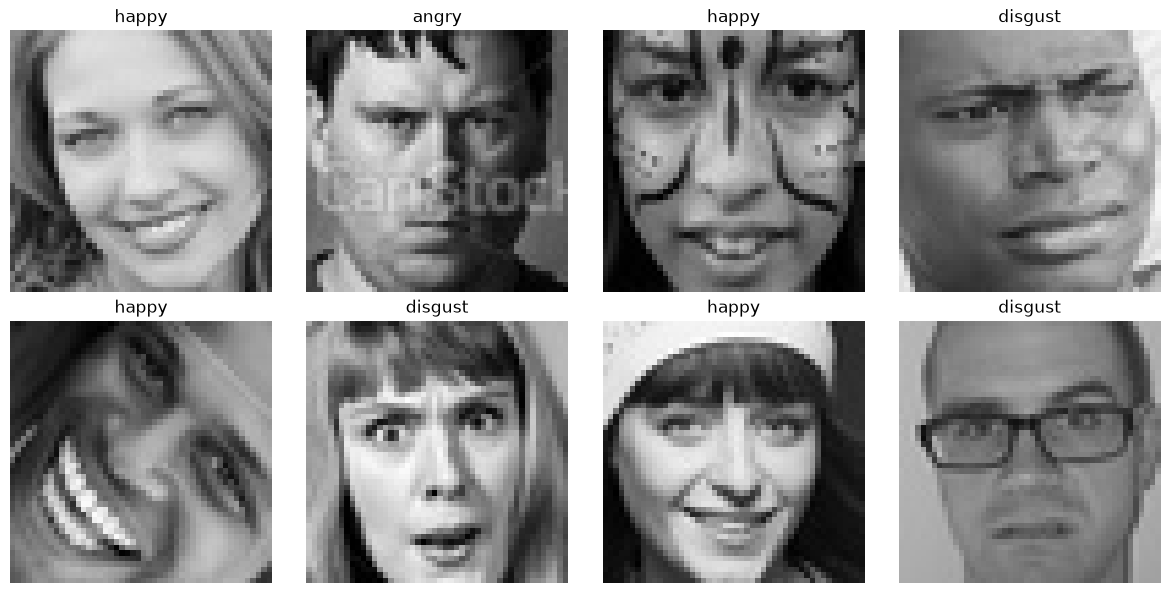

In [5]:
import cv2
import random

fig, axes = plt.subplots(2, 4,
                         figsize=(12, 6))

emotions = os.listdir(train_path)

for ax in axes.flatten():
    emotion = random.choice(emotions)

    img_path = os.path.join(
        train_path,
        emotion,
        random.choice(
            os.listdir(
                os.path.join(train_path, emotion)
            )
        )
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(img)
    ax.set_title(emotion)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    Input(shape=(48,48,1)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)